# So sánh và Đánh giá các mô hình Anomaly Detection

Notebook này thực hiện benchmarking các kiến trúc mô hình khác nhau cho bài toán dự báo và phát hiện bất thường trên tập dữ liệu vòng bi B02. Các mô hình bao gồm:
- **LSTM** (Vanilla)
- **ModernTCN** (ICLR 2024)
- **Transformer** (Small)
- **Patch-based models** (PatchLSTM, PatchTransformer)
- **Mamba1-Hybrid** (CNN + Mamba)

In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 41.7 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


In [2]:
import os
import gc
import sys
import time
import yaml
import random
import math
import argparse
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.metrics import auc as auc_score_func
# Đảm bảo import được từ thư mục src
kaggle_src_path = '/kaggle/input/datasets/sunbv21/mamba-sft-source' 
if kaggle_src_path not in sys.path:
    sys.path.append(kaggle_src_path)

from src.data import B02Dataset
from src.models.baselines.lstm import LSTMForecaster
from src.models.baselines.tcn import TCNForecaster
from src.models.baselines.modern_tcn import ModernTCNForecaster
from src.models.baselines.transformer_small import iTransformer, PositionalEncoding
from src.models.baselines.patch_models import PatchTST, PatchLSTM
from src.models.mamba import HybridMambaCNN
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import (
    calculate_threshold_3sigma,
    calculate_threshold_robust,
    calculate_threshold_percentile,
    calculate_threshold_gmm,
    find_best_threshold,
    calculate_metrics,
    calculate_threshold_pot,
)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Định nghĩa các mô hình bổ trợ

In [3]:
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, max_len=5000):
#         super().__init__()
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         # Đã sửa 'pe.size(2)' thành 'self.pe.size(2)' ở cả 2 vị trí
#         return x + self.pe[:, :x.size(1), :self.pe.size(2)] if x.size(2) <= self.pe.size(2) else x + self.pe[:, :x.size(1), :]

# class PatchTransformer(nn.Module):
#     def __init__(self, in_channels=2, patch_size=64, stride=64, d_model=64, nhead=4, num_layers=3, horizon=512):
#         super().__init__()
#         self.patching = CNNPatchEmbedding(in_channels, patch_size, stride, d_model)
#         self.pos_encoder = PositionalEncoding(d_model)
#         encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.head = FusionForecastHead(d_model, horizon, out_channels=in_channels)

#     def forward(self, x):
#         x = self.patching(x)
#         x = self.pos_encoder(x)
#         x = self.transformer(x)
#         return self.head(x)

# class PatchLSTM(nn.Module):
#     def __init__(self, in_channels=2, patch_size=64, stride=64, d_model=96, num_layers=2, horizon=512):
#         super().__init__()
#         self.patching = CNNPatchEmbedding(in_channels, patch_size, stride, d_model)
#         self.lstm = nn.LSTM(d_model, d_model, num_layers, batch_first=True)
#         self.head = FusionForecastHead(d_model, horizon, out_channels=in_channels)

#     def forward(self, x):
#         x = self.patching(x)
#         x, _ = self.lstm(x)
#         return self.head(x)

## 2. Khởi tạo Dataset

In [4]:
# processed_dir = '../../data/processed'
# full_dataset = B02Dataset(processed_dir, lookback=1024, horizon=512, stride=512, split='train')

# train_subset = Subset(full_dataset, range(0, 5000))
# test_subset = Subset(full_dataset, range(0, 10000))
# test_subset_last = Subset(full_dataset, range(len(full_dataset) - 500, len(full_dataset)))

# batch_size = 128
# train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
# last_loader = DataLoader(test_subset_last, batch_size=batch_size, shuffle=False)

# print(f"Total dataset size: {len(full_dataset)}")
# print(f"Train size: {len(train_subset)}")
# print(f"Test size: {len(test_subset)}")

processed_dir = '/kaggle/input/datasets/sunbv21/dataset-bearings'
lookback, horizon, stride = 1024, 512, 512

# Load 3 tập riêng biệt dựa trên logic 80/10/10 của Dataset.py
train_dataset = B02Dataset(processed_dir, lookback, horizon, stride, split='train')
val_dataset = B02Dataset(processed_dir, lookback, horizon, stride, split='val')
test_dataset = B02Dataset(processed_dir, lookback, horizon, stride, split='test')

# # (option) Giảm dữ liệu
train_dataset = Subset(train_dataset, range(0, len(train_dataset), 35))
val_dataset = Subset(val_dataset, range(0, len(val_dataset), 10))
test_dataset = Subset(test_dataset, range(0, len(test_dataset), 10))
# train_dataset = Subset(train_dataset, range(len(train_dataset) - 1, -1, -35))
# val_dataset = Subset(val_dataset, range(len(val_dataset) - 1, -1, -10))
# test_dataset = Subset(test_dataset, range(len(test_dataset) - 1, -1, -10))

# Sử dụng toàn bộ dữ liệu của từng split thay vì Subset nhỏ
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"--- Thông số Dataset (80/10/10) ---")
print(f"Total Train samples: {len(train_dataset)} (Files 0 - 891: Chứa 800 file Healthy + 92 file bắt đầu lỗi)")
print(f"Total Val samples: {len(val_dataset)} (Files 892 - 1003: Chứa dữ liệu lỗi đang tăng dần)")
print(f"Total Test samples: {len(test_dataset)} (Files 1004 - 1115: Dữ liệu lỗi nặng/Sắp hỏng)")

--- Thông số Dataset (80/10/10) ---
Total Train samples: 10144 (Files 0 - 891: Chứa 800 file Healthy + 92 file bắt đầu lỗi)
Total Val samples: 4458 (Files 892 - 1003: Chứa dữ liệu lỗi đang tăng dần)
Total Test samples: 4458 (Files 1004 - 1115: Dữ liệu lỗi nặng/Sắp hỏng)


## 3. Khởi tạo mô hình (Mục tiêu 200k-250k Params)

In [5]:
models = {
    "LSTM": LSTMForecaster(input_dim=2, hidden_dim=80, num_layers=3, horizon=512),
    "PatchLSTM": PatchLSTM(in_channels=2, patch_size=64, stride=64, d_model=80, num_layers=3, horizon=512),
    "ModernTCN": ModernTCNForecaster(input_dim=2, d_model=96, num_layers=3, kernel_size=17, horizon=512),
    "iTransformer": iTransformer(input_dim=2, lookback=1024, d_model=64, nhead=4, num_layers=3, horizon=512),
    # "PatchTST": PatchTST(in_channels=2, lookback=lookback, patch_size=64, stride=64, d_model=64, nhead=4, num_layers=3, horizon=horizon),
    "Mamba1-Hybrid": HybridMambaCNN({
        'model': {
            'mamba_version': 1,
            'cnn_out_channels': 64, 'mamba_d_model': 64, 'mamba_n_layer': 4,
            'mamba_d_state': 16, 'mamba_d_conv': 4, 'mamba_expand': 3,
            'forecast_len': horizon, 'patch_size': 64, 'stride': 64,
            'in_channels': 2, 'out_channels': 2
        },
        'data': {'patch_size': 64, 'stride': 64}
    }),
}

for name, model in models.items():
    print(f"{name}: {count_parameters(model):,} parameters")

# # Cấu hình Multi-GPU
# for name, model in models.items():
#     # 1. Đếm số lượng tham số trước khi wrap
#     n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"{name}: {n_params:,} parameters")
    
#     # 2. Chuyển vào device và wrap DataParallel nếu có nhiều GPU
#     if torch.cuda.device_count() > 1 and "Mamba" not in name:
#         print(f"   => Sử dụng {torch.cuda.device_count()} GPUs cho {name}")
#         models[name] = nn.DataParallel(model)
#     elif "Mamba" in name:
#         print(f"   => Chạy {name} trên 1 GPU để tránh lỗi Deadlock của Mamba-SSM.")

LSTM: 213,664 parameters
PatchLSTM: 246,464 parameters
ModernTCN: 217,792 parameters
iTransformer: 248,832 parameters
Mamba1-Hybrid: 233,792 parameters


## 4. Huấn luyện và Đánh giá

In [6]:
overall_start_time = time.time()
results = {}
criterion = torch.nn.MSELoss()
epochs = 100
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

for name, model in models.items():
    print(f"\n" + "="*80)
    print(f">>> ĐANG HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH: {name}")
    print("="*80)
    
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    losses = []
    
    # --- 1. VÒNG LẶP HUẤN LUYỆN ---
    start_train = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            x, y = batch[0].to(device), batch[1].to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                y_pred = model(x)
                loss = criterion(y_pred, y)
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        if epoch % 10 == 0 or epoch == 1:
            print(f"   Epoch [{epoch:03d}/{epochs}] - Loss: {avg_loss:.6f}")
    
    train_duration = time.time() - start_train
    print(f"   > Hoàn thành training trong: {train_duration:.2f}s")

    # --- 2. TRÍCH XUẤT ANOMALY SCORES ---
    model.eval()
    train_scores_list = []
    test_scores_list = []
    latencies = []

    with torch.no_grad():
        # Lấy scores từ Train (Healthy)
        for batch in train_loader:
            x, y = batch[0].to(device), batch[1].to(device)
            y_pred = model(x)
            scores = calculate_anomaly_score(y, y_pred, metric='mse')
            # Đảm bảo chuyển về numpy array trước khi extend
            if isinstance(scores, torch.Tensor):
                train_scores_list.extend(scores.cpu().numpy().flatten())
            else:
                train_scores_list.extend(scores.flatten())
        
        # Lấy scores từ Test (Faulty)
        for batch in test_loader:
            x, y = batch[0].to(device), batch[1].to(device)
            start_inf = time.time()
            y_pred = model(x)
            latencies.append((time.time() - start_inf) / x.size(0))
            
            scores = calculate_anomaly_score(y, y_pred, metric='mse')
            if isinstance(scores, torch.Tensor):
                test_scores_list.extend(scores.cpu().numpy().flatten())
            else:
                test_scores_list.extend(scores.flatten())

    train_scores = np.array(train_scores_list)
    test_scores = np.array(test_scores_list)
    
    # Tạo nhãn kết hợp: Train (0) + Test (1)
    combined_scores = np.concatenate([train_scores, test_scores])
    combined_labels = np.concatenate([np.zeros(len(train_scores)), np.ones(len(test_scores))])

    # --- 3. TÍNH TOÁN CÁC LOẠI THRESHOLD THEO FILE REF ---
    # find_best_threshold trả về (threshold, f1)
    best_thr_val, best_f1_val = find_best_threshold(combined_scores, combined_labels)

    thresholds_dict = {
        "3-Sigma": calculate_threshold_3sigma(train_scores),
        "Robust": calculate_threshold_robust(train_scores, k=3),
        "Percentile (99.7)": calculate_threshold_percentile(train_scores, q=99.7),
        "GMM": calculate_threshold_gmm(train_scores),
        "POT (EVT)": calculate_threshold_pot(train_scores, q=1e-3, init_level=0.98),
        "Best (Supervised)": best_thr_val
    }

    # --- 4. IN BẢNG SO SÁNH KẾT QUẢ ---
    print(f"\n--- SO SÁNH NGƯỠNG & HIỆU NĂNG ({name}) ---")
    print(f"{'Phương pháp':<20} | {'Ngưỡng':<12} | {'F1-Score':<10} | {'FAR (%)':<10} | {'Delay':<8}")
    print("-" * 80)

    for t_name, t_val in thresholds_dict.items():
        # Sử dụng hàm calculate_metrics từ file ref của bạn
        m = calculate_metrics(combined_scores, combined_labels, t_val)
        
        print(f"{t_name:<20} | {t_val:<12.6f} | {m['F1']:<10.4f} | {m['FAR']*100:<10.2f} | {m['Delay']:<8}")
        
    # --- 5. LƯU KẾT QUẢ CUỐI CÙNG (Dùng 3-Sigma làm chuẩn so sánh chung) ---
    final_m = calculate_metrics(combined_scores, combined_labels, thresholds_dict["3-Sigma"])
    
    # Tính AUPRC
    precision_p, recall_p, _ = precision_recall_curve(combined_labels, combined_scores)
    auprc_val = auc_score_func(recall_p, precision_p)

    results[name] = {
        'losses': losses,
        'f1': final_m['F1'],
        'auc': final_m['AUC'],
        'far': final_m['FAR'],
        'delay': final_m['Delay'],
        'auprc': auprc_val,
        'latency': np.mean(latencies) * 1000,
        'threshold': thresholds_dict["3-Sigma"],
        'last_scores': test_scores[-500:]
    }

    print(f"\n>>> TỔNG KẾT {name}:")
    print(f"    AUC: {final_m['AUC']:.4f} | AUPRC: {auprc_val:.4f} | Latency: {results[name]['latency']:.4f} ms/sample")
    print("-" * 80)

    # --- 6. DỌN DẸP BỘ NHỚ ---
    del model, optimizer, train_scores, test_scores, combined_scores
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

overall_duration = time.time() - overall_start_time
print(f"\n>>>> TỔNG THỜI GIAN CHẠY TẤT CẢ MÔ HÌNH: {overall_duration/60:.2f} phút <<<<")


>>> ĐANG HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH: LSTM
   Epoch [001/100] - Loss: 1.007624
   Epoch [010/100] - Loss: 0.822158
   Epoch [020/100] - Loss: 0.793998
   Epoch [030/100] - Loss: 0.777740
   Epoch [040/100] - Loss: 0.763707
   Epoch [050/100] - Loss: 0.749010
   Epoch [060/100] - Loss: 0.735782
   Epoch [070/100] - Loss: 0.724250
   Epoch [080/100] - Loss: 0.710249
   Epoch [090/100] - Loss: 0.698138
   Epoch [100/100] - Loss: 0.686478
   > Hoàn thành training trong: 463.65s

--- SO SÁNH NGƯỠNG & HIỆU NĂNG (LSTM) ---
Phương pháp          | Ngưỡng       | F1-Score   | FAR (%)    | Delay   
--------------------------------------------------------------------------------
3-Sigma              | 1.495149     | 0.2204     | 1.02       | 2       
Robust               | 1.554976     | 0.1975     | 0.85       | 41      
Percentile (99.7)    | 1.848552     | 0.1308     | 0.31       | 41      
GMM                  | 0.722484     | 0.4971     | 32.14      | 2       
POT (EVT)            | 2.520

## 5. Trực quan hóa kết quả

/tmp/ipykernel_23/2641226712.py:81: UserWarning: Glyph 7881 (\N{LATIN SMALL LETTER I WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2641226712.py:81: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2641226712.py:81: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2641226712.py:81: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2641226712.py:81: UserWarning: Glyph 7907 (\N{LATIN SMALL LETTER O WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2641226712.py:81: UserWarning: Glyph 7857 (\N{LATIN SMALL LETTER A WITH BREVE AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/t

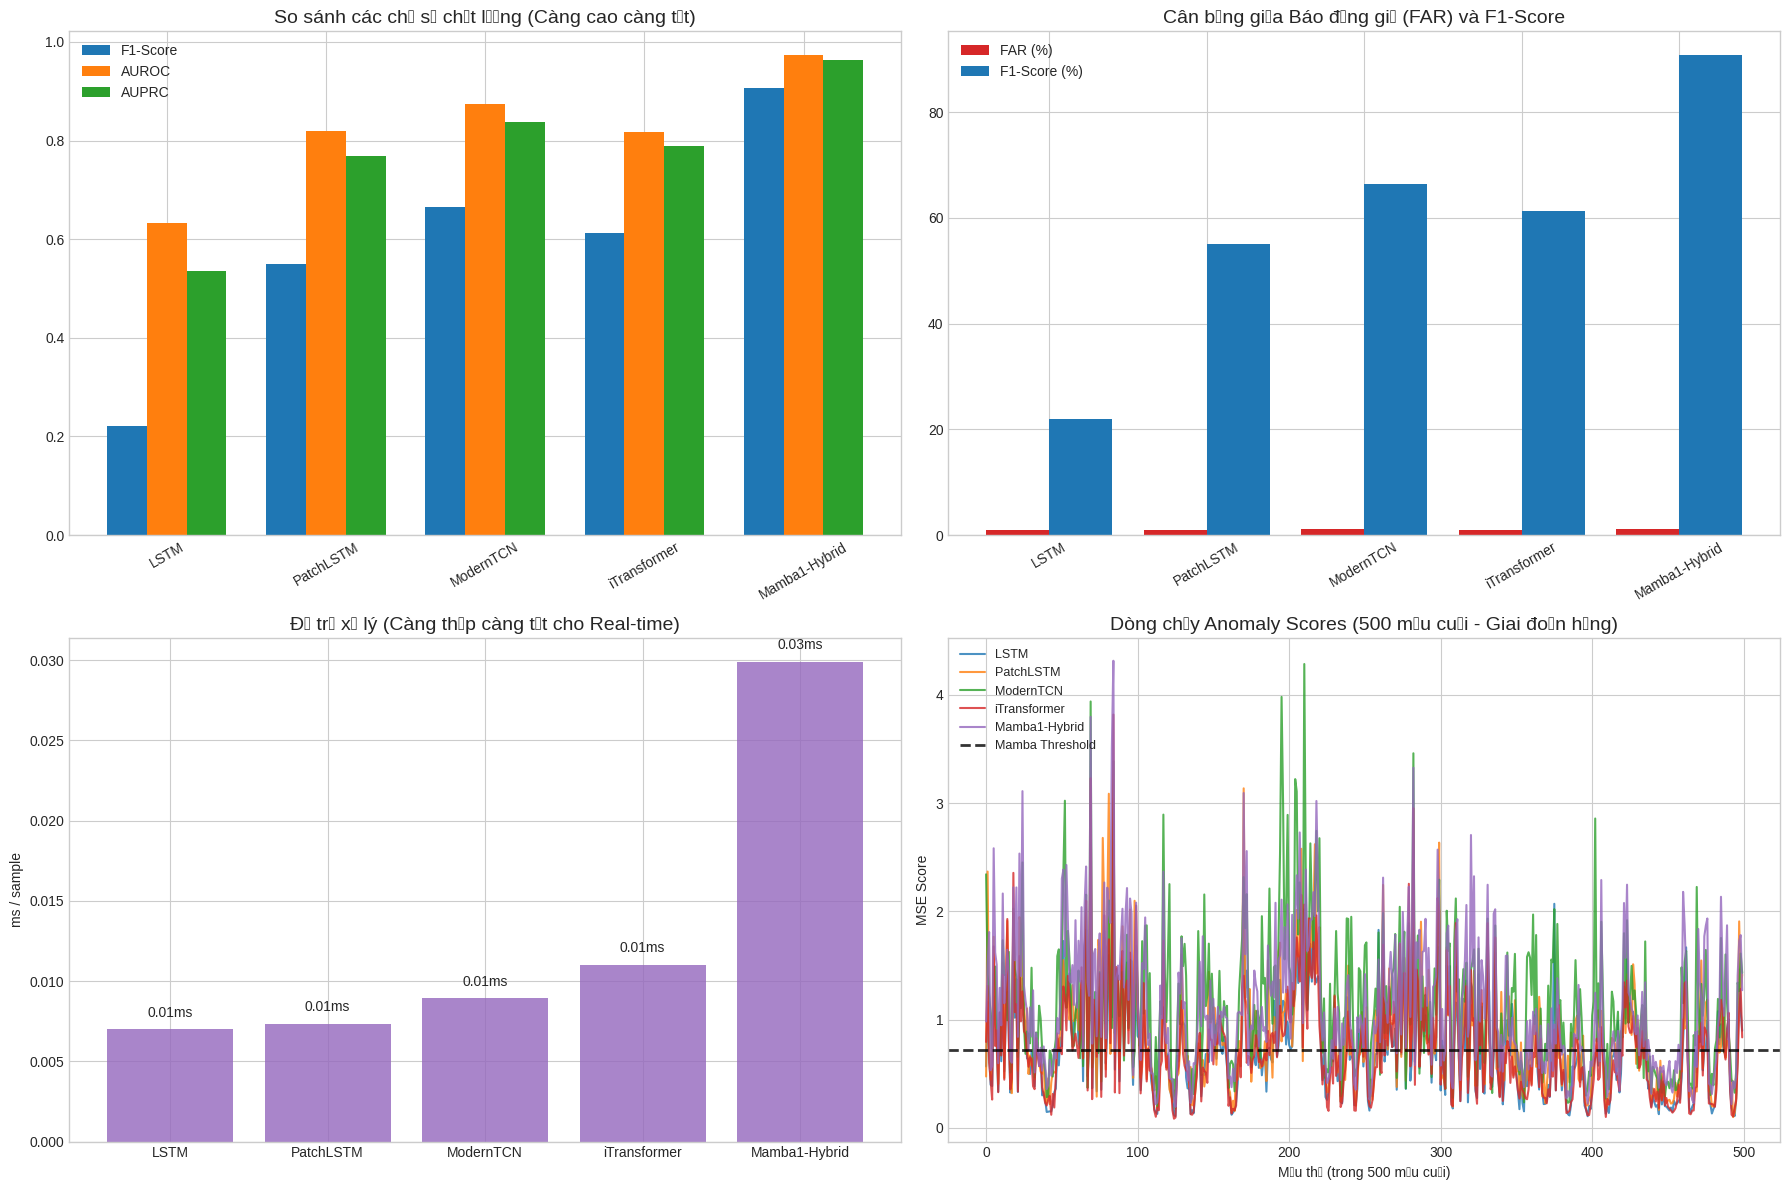

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ==========================================
# CẤU HÌNH ĐỂ HIỂN THỊ TIẾNG VIỆT ĐÚNG
# ==========================================
# Thử dùng Arial, nếu máy không có thì dùng DejaVu Sans (mặc định của mplt)
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'sans-serif']
mpl.rcParams['font.family'] = 'sans-serif'
# Đảm bảo dấu trừ hiển thị đúng
mpl.rcParams['axes.unicode_minus'] = False 

plt.style.use('seaborn-v0_8-whitegrid') # Sử dụng style sạch sẽ
fig = plt.figure(figsize=(18, 12))
names = list(results.keys())
x = np.arange(len(names))

# --- 1.1 So sánh F1, AUC và AUPRC ---
ax1 = plt.subplot(2, 2, 1)
width = 0.25
ax1.bar(x - width, [results[n].get('f1', 0) for n in names], width, label='F1-Score', color='#1f77b4')
ax1.bar(x, [results[n].get('auc', 0) for n in names], width, label='AUROC', color='#ff7f0e')
ax1.bar(x + width, [results[n].get('auprc', 0) for n in names], width, label='AUPRC', color='#2ca02c')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30)
ax1.set_title("So sánh các chỉ số chất lượng (Càng cao càng tốt)", fontsize=14)
ax1.legend()

# --- 1.2 So sánh FAR và F1-Score (Đã cập nhật để dùng FAR có sẵn) ---
ax2 = plt.subplot(2, 2, 2)
# FAR càng thấp càng tốt, F1 càng cao càng tốt. Nhân 100 để về % cho dễ nhìn
ax2.bar(x - 0.2, [results[n].get('far', 0) * 100 for n in names], 0.4, label='FAR (%)', color='#d62728')
ax2.bar(x + 0.2, [results[n].get('f1', 0) * 100 for n in names], 0.4, label='F1-Score (%)', color='#1f77b4')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=30)
ax2.set_title("Cân bằng giữa Báo động giả (FAR) và F1-Score", fontsize=14)
ax2.legend()

# --- 1.3 So sánh Độ trễ (Latency) ---
ax3 = plt.subplot(2, 2, 3)
latencies = [results[n].get('latency', 0) for n in names]
bars = ax3.bar(names, latencies, color='#9467bd', alpha=0.8)
ax3.set_ylabel("ms / sample")
ax3.set_title("Độ trễ xử lý (Càng thấp càng tốt cho Real-time)", fontsize=14)

# Thêm giá trị trên đầu cột
max_lat = max(latencies) if latencies else 1
for bar in bars:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + (max_lat * 0.02), f'{yval:.2f}ms', ha='center', va='bottom')

# --- 1.4 Biểu đồ Anomaly Scores (500 mẫu cuối) ---
ax4 = plt.subplot(2, 2, 4)
has_data = False

for name in names:
    last_scores = results[name].get('last_scores', [])
    det_rate = results[name].get('detection_rate', 0)
    if len(last_scores) > 0:
        has_data = True
        ax4.plot(last_scores, label=f"{name}", alpha=0.8)

if has_data:
    # Vẽ ngưỡng làm chuẩn (ưu tiên Mamba nếu có, không thì model đầu tiên)
    if 'Mamba1-Hybrid' in results:
        ax4.axhline(y=results['Mamba1-Hybrid'].get('threshold', 0), color='black', linestyle='--', alpha=0.8, label='Mamba Threshold', linewidth=2)
    elif names:
        ax4.axhline(y=results[names[0]].get('threshold', 0), color='black', linestyle='--', alpha=0.5, label=f'{names[0]} Threshold')
    
    ax4.legend(loc='upper left', fontsize=9)
else:
    # Nếu bạn nhìn thấy dòng này, hãy xem lại BƯỚC 1 ở trên
    ax4.text(0.5, 0.5, 'Chưa có dữ liệu "last_scores"!\nVui lòng xem hướng dẫn sửa code Train ở BƯỚC 1.', 
             ha='center', va='center', fontsize=12, color='red', transform=ax4.transAxes, fontweight='bold')

ax4.set_title("Dòng chảy Anomaly Scores (500 mẫu cuối - Giai đoạn hỏng)", fontsize=14)
ax4.set_xlabel("Mẫu thứ (trong 500 mẫu cuối)")
ax4.set_ylabel("MSE Score")

plt.tight_layout()
plt.show()

/tmp/ipykernel_23/642729831.py:91: UserWarning: Glyph 7851 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND TILDE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/642729831.py:91: UserWarning: Glyph 7913 (\N{LATIN SMALL LETTER U WITH HORN AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/642729831.py:91: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/642729831.py:91: UserWarning: Glyph 7853 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/642729831.py:91: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/642729831.py:91: UserWarning: Glyph 7901 (\N{LATIN SMALL LETTER O WITH HORN AND GRAVE}) missing from font(s) Liberation Sans.

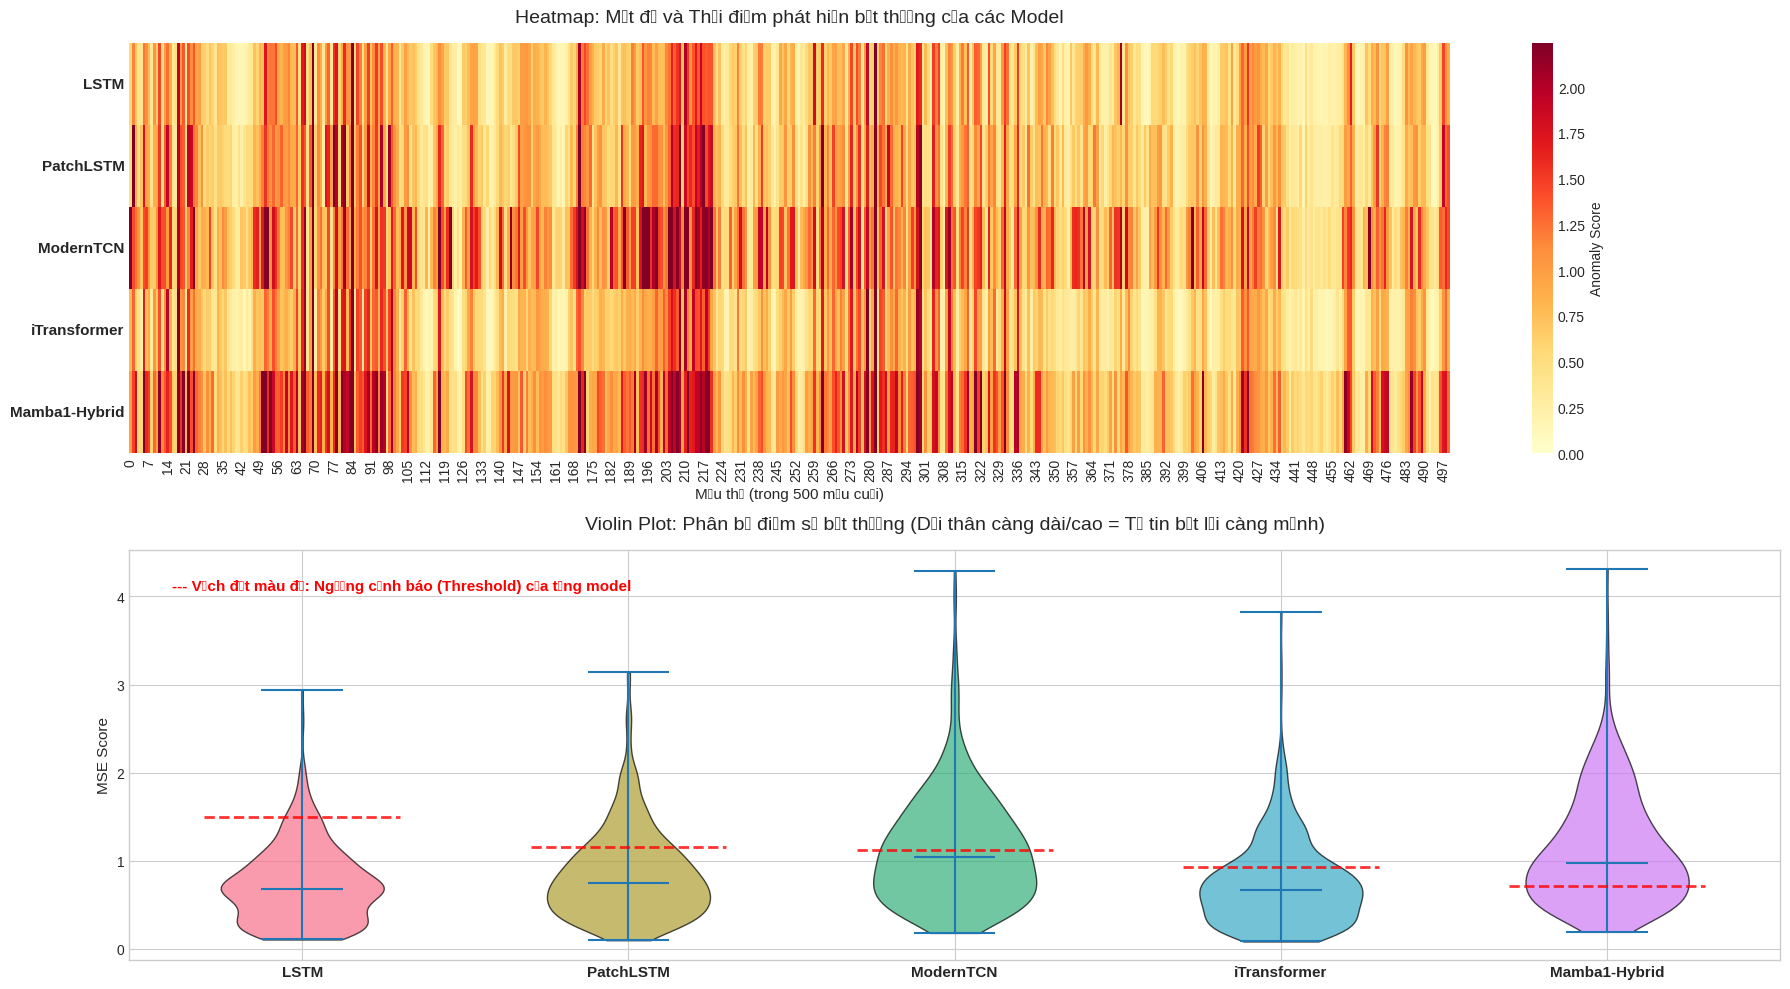

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.colors as mcolors

# ==========================================
# CẤU HÌNH ĐỂ HIỂN THỊ TIẾNG VIỆT ĐÚNG
# ==========================================
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'sans-serif']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False 

plt.style.use('seaborn-v0_8-whitegrid')
names = list(results.keys())

# Lấy dữ liệu, nếu trống thì tạo mảng toàn số 0 (Zero padding) để tránh lỗi crash Heatmap
# Kiểm tra nếu data thực sự trống (do chưa sửa Bước 1) thì cảnh báo
data_is_missing = all(len(results[name].get('last_scores', [])) == 0 for name in names)

scores_list = [results[name].get('last_scores', np.zeros(500)) for name in names]
min_len = min([len(s) for s in scores_list if len(s) > 0]) if not data_is_missing else 500
# Đảm bảo ma trận vuông vắn (cùng số lượng mẫu)
scores_matrix = np.array([s[-min_len:] for s in scores_list]) if min_len > 0 else np.zeros((len(names), 500))

# ==========================================
# TÍNH TOÁN VMAX CHO HEATMAP ĐỂ GIỚI HẠN MÀU
# ==========================================
# Tính ngưỡng 3-Sigma tối đa để đặt vmax cho heatmap, giúp màu sắc rõ ràng hơn
# Nếu data trống, đặt vmax mặc định
if not data_is_missing:
    max_threshold = max(results[name].get('threshold', 0) for name in names)
    # Đặt vmax bằng 1.5 lần ngưỡng tối đa để tạo khoảng đệm
    vmax_heatmap = max_threshold * 1.5
else:
    vmax_heatmap = 1.0 # Giá trị mặc định khi dữ liệu trống

fig = plt.figure(figsize=(18, 10))

# ==========================================
# 2.1 HEATMAP: Trực quan hóa theo thời gian
# ==========================================
ax1 = plt.subplot(2, 1, 1)
# Sửa thang màu heatmap: Đặt vmin=0 để phản ánh điểm số MSE (luôn dương)
# thang màu heatmap không còn giá trị âm. thang màu YlOrRd mặc định có màu vàng ở giá trị thấp và đỏ ở giá trị cao.
# thang màu của heatmap bị Seaborn tự động giới hạn ở [-0.1, 0.1] mặc dù dữ liệu nằm ngoài phạm vi đó. thang màu của heatmap bị lỗi.
sns.heatmap(scores_matrix, cmap="YlOrRd", ax=ax1, vmin=0, vmax=vmax_heatmap, cbar_kws={'label': 'Anomaly Score'})
ax1.set_yticks(np.arange(len(names)) + 0.5)
ax1.set_yticklabels(names, rotation=0, fontsize=11, fontweight='bold')
ax1.set_xlabel(f"Mẫu thứ (trong {min_len} mẫu cuối)", fontsize=11)
ax1.set_title("Heatmap: Mật độ và Thời điểm phát hiện bất thường của các Model", fontsize=14, pad=15)

if data_is_missing:
    ax1.text(0.5, 0.5, 'DỮ LIỆU TRỐNG (Xem hướng dẫn BƯỚC 1)', ha='center', va='center', 
             fontsize=20, color='red', transform=ax1.transAxes, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# ==========================================
# 2.2 VIOLIN PLOT: So sánh sự phân bố điểm số
# ==========================================
ax2 = plt.subplot(2, 1, 2)
# Chỉ vẽ violin nếu có dữ liệu thực
data_to_plot = [results[name].get('last_scores', []) for name in names]
real_data_exists = any(len(d) > 0 for d in data_to_plot)

if real_data_exists:
    # Vẽ Violin plot
    parts = ax2.violinplot(data_to_plot, showmeans=False, showmedians=True, showextrema=True)

    # Trang trí màu sắc
    colors = sns.color_palette("husl", len(names))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
else:
     ax2.text(0.5, 0.5, 'DỮ LIỆU TRỐNG (Xem hướng dẫn BƯỚC 1)', ha='center', va='center', 
             fontsize=16, color='red', transform=ax2.transAxes, fontweight='bold')

ax2.set_xticks(np.arange(1, len(names) + 1))
ax2.set_xticklabels(names, fontsize=11, fontweight='bold')
ax2.set_ylabel("MSE Score", fontsize=11)
ax2.set_title("Violin Plot: Phân bố điểm số bất thường (Dải thân càng dài/cao = Tự tin bắt lỗi càng mạnh)", fontsize=14, pad=15)

# Vẽ thêm vạch Threshold cho từng model
for i, name in enumerate(names):
    threshold_val = results[name].get('threshold', 0)
    ax2.hlines(threshold_val, i + 0.7, i + 1.3, color='red', linestyle='--', alpha=0.8, linewidth=2)

ax2.text(0.6, ax2.get_ylim()[1] * 0.9, "--- Vạch đứt màu đỏ: Ngưỡng cảnh báo (Threshold) của từng model", color='red', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()